# NIfTI geometry and resampling

Same lesson as [readme.md](readme.md), with the pictures.

Two viewers are used on purpose:

- **matplotlib** draws the data array. A panel is a plane of voxel indices. The affine is ignored, so a tilted volume looks crooked here even when it is the same ball in the scanner.
- **NiiVue** (`ipyniivue`) draws the NIfTI in world millimetres. It reads the affine. The axial ball and the tilted ball land on top of each other. Scroll a slice to move through the volume. Drag the 3D panel to rotate. The crosshair numbers are millimetres.

NiiVue is WebGL, so it stays quick on a real scan. It is the same engine as the NiiVue extension for VS Code and Cursor (`KorbinianEckstein.niivue`). After this notebook writes `output/*.nii.gz`, you can open those files in the editor: click one, or select two and run **NiiVue: Compare**. That view needs no kernel.

The registration Colab draws slices and a nilearn HTML view. This notebook keeps that slice picture, and adds NiiVue for the 3D world-space view.

```
pip install numpy scipy nibabel matplotlib ipyniivue
```

Run it from this folder in JupyterLab, VS Code, or Cursor. On GitHub the NiiVue panels are empty until the cells run.

In [1]:
%matplotlib inline

from pathlib import Path

import matplotlib.pyplot as plt
import nibabel as nib
import numpy as np
from ipyniivue import MultiplanarType, NiiVue, ShowRender, SliceType, Volume

import resample_examples as geo

OUT = Path(geo.__file__).resolve().parent / "output"
OUT.mkdir(exist_ok=True)

def save(data, affine, name):
    path = OUT / name
    nib.save(nib.Nifti1Image(np.asarray(data, np.float32), affine), path)
    return path

def index_slices(rows):
    """rows: list of (title, array). Each row is the middle i, j and k index plane."""
    fig, axes = plt.subplots(
        len(rows), 3, figsize=(9, 3.2 * len(rows)), squeeze=False, layout="constrained"
    )
    for row, (title, data) in enumerate(rows):
        mid = [n // 2 for n in data.shape[:3]]
        planes = [
            (data[mid[0], :, :].T, f"fixed i = {mid[0]}"),
            (data[:, mid[1], :].T, f"fixed j = {mid[1]}"),
            (data[:, :, mid[2]].T, f"fixed k = {mid[2]}"),
        ]
        for ax, (plane, label) in zip(axes[row], planes):
            ax.imshow(plane, cmap="gray", origin="lower", vmin=0, vmax=2)
            ax.set_title(label)
            ax.set_xlabel("voxel index")
        axes[row, 0].set_ylabel(title)
    plt.show()

def show_niivue(paths, colormaps=None, opacities=None, height=560):
    """Embedded NiiVue. Last line of a cell, so the widget draws."""
    paths = list(paths)
    if colormaps is None:
        colormaps = ["gray"] * len(paths)
    if opacities is None:
        opacities = [1.0] * len(paths)
    volumes = [
        Volume(path=path, colormap=cmap, opacity=opacity, cal_min=0.0, cal_max=2.0)
        for path, cmap, opacity in zip(paths, colormaps, opacities)
    ]
    nv = NiiVue(
        height=height,
        slice_type=SliceType.MULTIPLANAR,
        multiplanar_show_render=ShowRender.ALWAYS,
        multiplanar_layout=MultiplanarType.GRID,
        is_slice_mm=True,
        is_colorbar=True,
    )
    nv.load_volumes(volumes)
    return nv

## Build the grids

Source: 32³, 2 mm, axes parallel to the world. Target: 48³, 1.5 mm, tilted 25° about x. The ball has value 1, and 2 where world z is positive, so the bright half shows orientation.

The plane is one slice, shape `(80, 80, 1)`, 1 mm in plane, 4 mm thick, same tilt. `slab` is that slice painted back into the coarse grid.

In [2]:
source_shape = (32, 32, 32)
source_affine = geo.affine_centered(source_shape, spacing=(2.0, 2.0, 2.0))
tilt = geo.rotation_about_x(25)
target_shape = (48, 48, 48)
target_affine = geo.affine_centered(target_shape, spacing=(1.5, 1.5, 1.5), rotation=tilt)

source = geo.ball_on_grid(source_shape, source_affine)
on_tilted = geo.resample_to_grid(source, source_affine, target_shape, target_affine)
back = geo.resample_to_grid(on_tilted, target_affine, source_shape, source_affine)

plane_shape = (80, 80, 1)
plane_affine = geo.affine_centered(plane_shape, spacing=(1.0, 1.0, 4.0), rotation=tilt)
plane = geo.resample_to_grid(source, source_affine, plane_shape, plane_affine)
slab = geo.place_slice_in_volume(plane[:, :, 0], plane_affine, source_shape, source_affine)

path_source = save(source, source_affine, "source.nii.gz")
path_tilted = save(on_tilted, target_affine, "tilted.nii.gz")
path_back = save(back, source_affine, "back.nii.gz")
path_plane = save(plane, plane_affine, "plane.nii.gz")
path_slab = save(slab, source_affine, "slice_in_volume.nii.gz")

print("source", source.shape, "spacing", np.round(np.linalg.norm(source_affine[:3, :3], axis=0), 2))
print("tilted", on_tilted.shape, "spacing", np.round(np.linalg.norm(target_affine[:3, :3], axis=0), 2))
print("round trip mean abs diff", float(np.mean(np.abs(back - source))))

source (32, 32, 32) spacing [2. 2. 2.]
tilted (48, 48, 48) spacing [1.5 1.5 1.5]
round trip mean abs diff 0.020891405642032623


## Index slices ignore the tilt

Both rows cut the array at the middle index. On the axial grid the bright half is a clean cap. On the tilted grid the same index planes cut the ball at an angle, and the voxels are smaller, so the drawing is a different size. These pictures are not in millimetres.

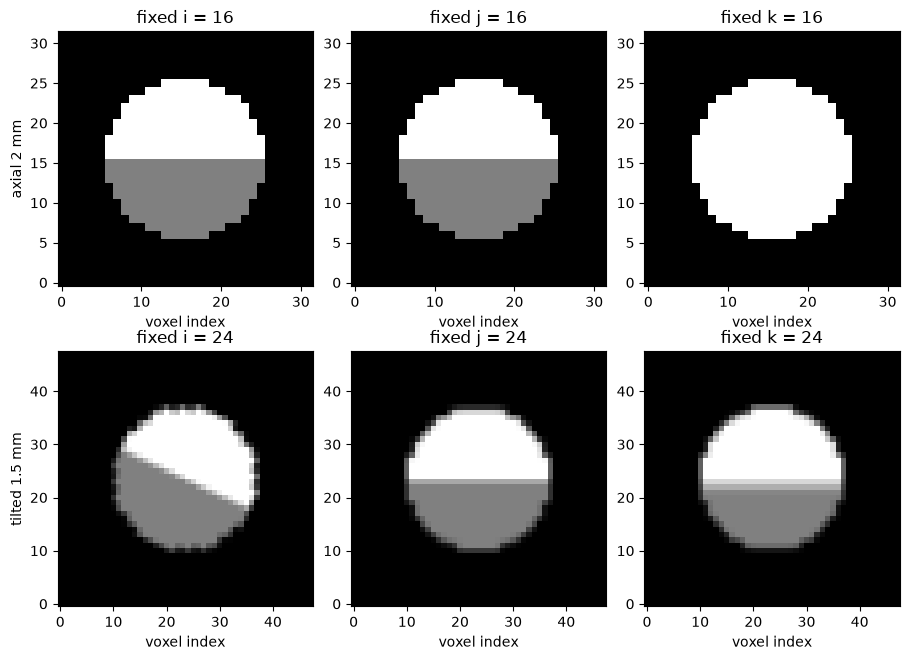

In [3]:
index_slices([
    ("axial 2 mm", source),
    ("tilted 1.5 mm", on_tilted),
])

## Same ball, world space

NiiVue places each voxel with the affine. The green volume is the tilted grid drawn on top of the gray one. The bright cap points the same way in both. Opacity on the green layer lets the gray one show through.

Open `output/source.nii.gz` and `output/tilted.nii.gz` together with **NiiVue: Compare** if you want this view in the editor instead of the notebook.

In [ ]:
show_niivue([path_source])

In [ ]:
show_niivue([path_tilted])

In [ ]:
show_niivue(
    [path_source, path_tilted],
    colormaps=["gray", "green"],
    opacities=[1.0, 0.45],
)

## Back onto the coarse grid

Same resample function, grids swapped. The shape matches the source again. Edges are softer, and the `k` slice picks up stripes: that is the tilted sampling grid, seen again along a voxel index. Linear interpolation does not undo itself.

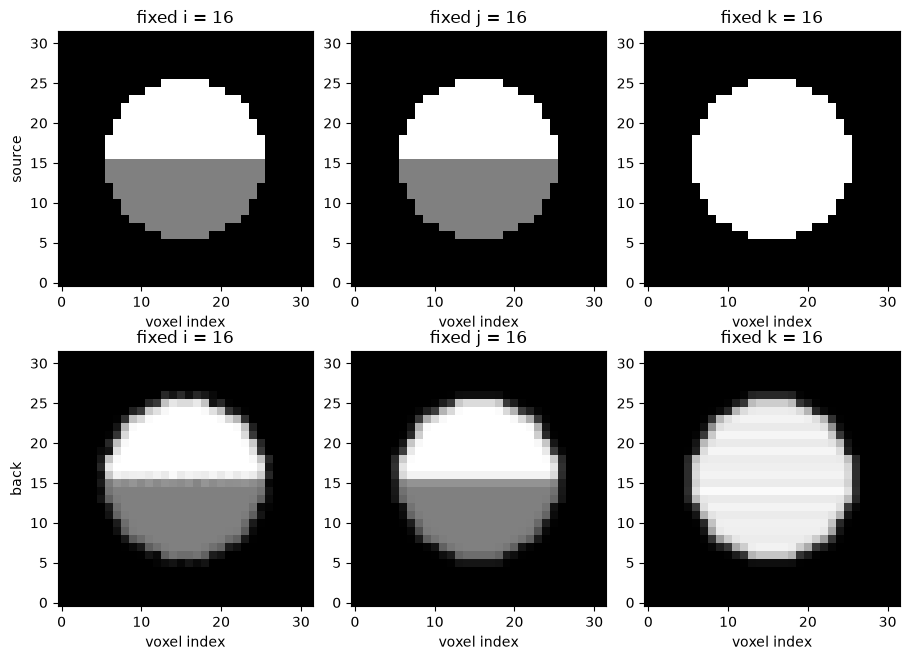

In [4]:
index_slices([
    ("source", source),
    ("back", back),
])

In [ ]:
show_niivue(
    [path_source, path_back],
    colormaps=["gray", "warm"],
    opacities=[1.0, 0.45],
)

## 3D onto one tilted plane

The plane is a NIfTI with a single voxel along its normal. The matplotlib panel is that 2D array. In NiiVue the orthogonal panels cut the sheet along a line, and the 3D panel shows the sheet itself.

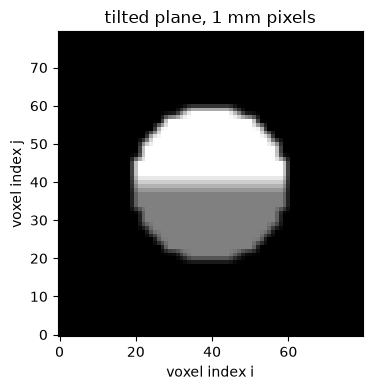

In [5]:
fig, ax = plt.subplots(figsize=(4, 4))
ax.imshow(plane[:, :, 0].T, cmap="gray", origin="lower", vmin=0, vmax=2)
ax.set_title("tilted plane, 1 mm pixels")
ax.set_xlabel("voxel index i")
ax.set_ylabel("voxel index j")
fig.tight_layout()
plt.show()

In [ ]:
show_niivue([path_plane])

## That plane painted into the 3D grid

The lower index-slice row is the slab: the coarse shape, with values only within 2 mm of the tilted plane. In NiiVue that slab is the red layer on the gray ball. The ball does not come back.

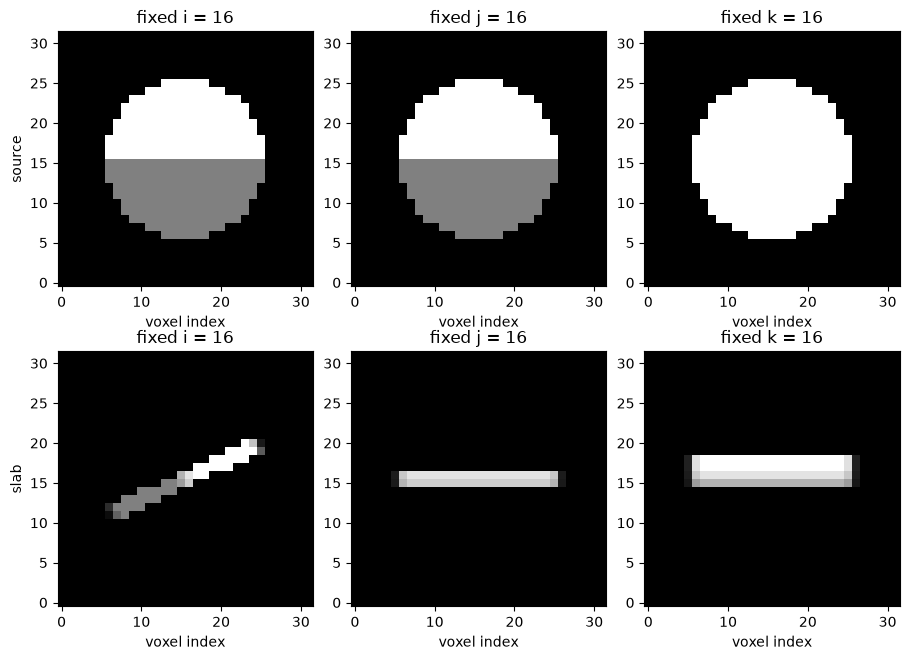

In [6]:
index_slices([
    ("source", source),
    ("slab", slab),
])

In [ ]:
show_niivue(
    [path_source, path_slab],
    colormaps=["gray", "red"],
    opacities=[0.35, 1.0],
)